In [1]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt
import sklearn.gaussian_process
import scipy.optimize as sco 
import pandas as pd
import sklearn
import scipy.linalg as sla

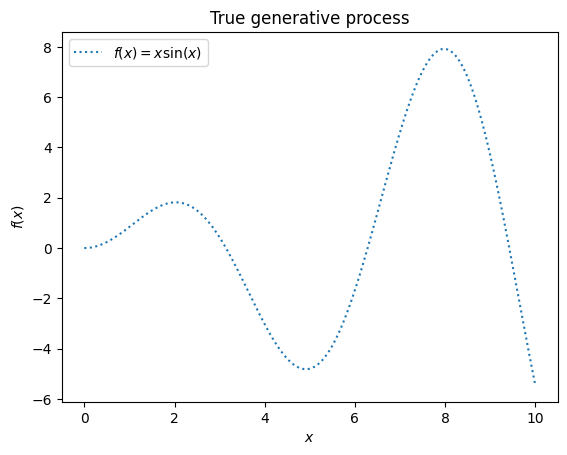

In [2]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [3]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor()
gaussian_process.fit(X_train, y_train)

,kernel,None
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None


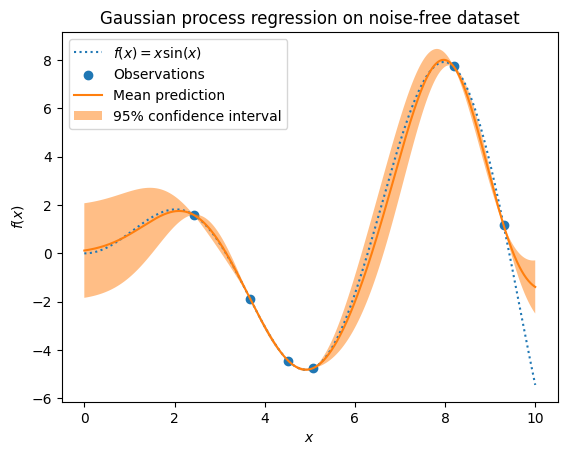

In [4]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor()
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
# preds.append(mean_prediction)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

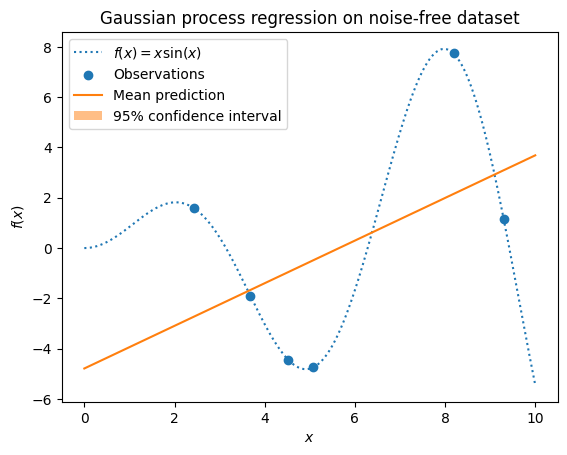

In [5]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
# preds.append(mean_prediction)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

In [6]:
sigma = 1
d = 1
np.random.seed(2)
w = np.random.randn(d)
eps = scs.norm.rvs(loc=0, scale=sigma, size=X.shape[0])
y = np.dot(X, w) + eps
training_indices = np.random.choice(np.arange(y.size), size=6, replace=False)

c:\Users\gusca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))
c:\Users\gusca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


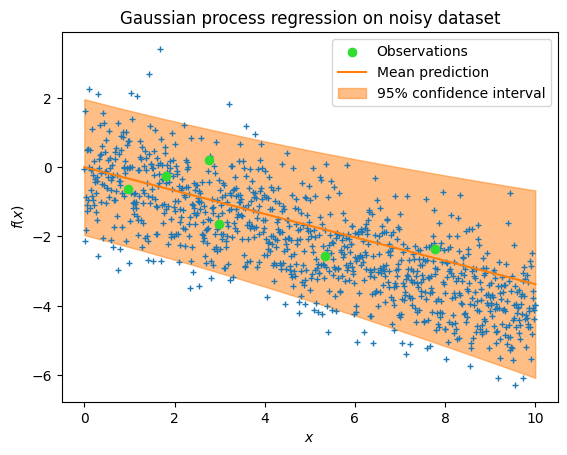

In [7]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct(sigma_0=0), alpha=sigma**2)
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
std_pred_bruitee = np.sqrt(std_prediction**2 + sigma**2)
# preds.append(mean_prediction)
plt.plot(X, y, linestyle="", marker="+", markersize=4)
plt.scatter(X_train, y_train, label="Observations", color="#30DD30", zorder=3)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_pred_bruitee,
    mean_prediction + 1.96 * std_pred_bruitee,
    alpha=0.5,
    label=r"95% confidence interval",
    color="C1",
    
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noisy dataset")

In [8]:
df = pd.read_csv("./data/airfoil_self_noise.dat", sep="\t", header=None, names=["Frequency", "Angle of attack", "Chord length", "Free-stream velocity", "Suction side displacement thickness", "Scaled sound pressure level"])

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
n_comp = 2

# Use the airfoil predictors (not the old 1D synthetic X from previous cells)
X = df.drop(columns=["Scaled sound pressure level"]).values

def pipeline_pca(n_comp):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp))
    ])
    return pipeline

X_pca = pipeline_pca(n_comp).fit_transform(X)

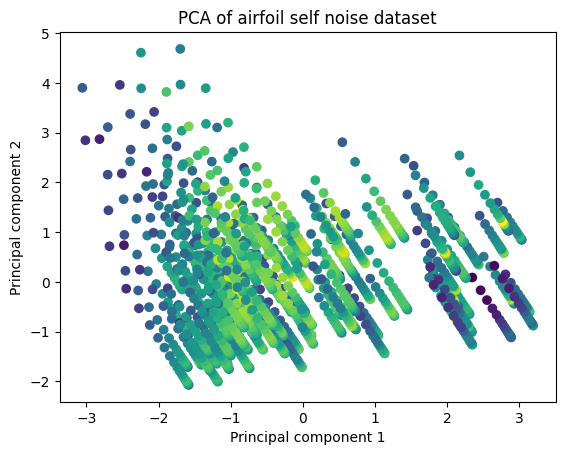

In [10]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Scaled sound pressure level"], cmap="viridis")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
_ = plt.title("PCA of airfoil self noise dataset")

In [11]:
# on normalise X
scaler = StandardScaler()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, df["Scaled sound pressure level"], test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
from sklearn.gaussian_process.kernels import WhiteKernel
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct()+ WhiteKernel())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)


In [13]:
var_pred = std_prediction**2

log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_pred)
    + (y_test - mean_prediction)**2 / var_pred
)

mean_log_likelihood = np.mean(log_likelihoods)
total_log_likelihood = np.sum(log_likelihoods)

print("Mean predictive log-likelihood:", mean_log_likelihood)
print("Total predictive log-likelihood:", total_log_likelihood)

lower1 = mean_prediction - 1.96 * std_prediction
upper1 = mean_prediction + 1.96 * std_prediction
coverage1 = np.mean((y_test >= lower1) & (y_test <= upper1))


print("Coverage avec std_prediction :", coverage1)

Mean predictive log-likelihood: -2.972206065433264
Total predictive log-likelihood: -894.6340256954124
Coverage avec std_prediction : 0.9501661129568106


In [14]:
gaussian_process.kernel_

DotProduct(sigma_0=125) + WhiteKernel(noise_level=23.4)

## Maintenant on la fait nous même

In [ ]:
class reg_gaussienne():
    def __init__(self, sigma_0=None, sigma=None):
        self.sigma_0 = sigma_0
        self.sigma = sigma
        self.fitted = False
        self.K_inv = None
        self.gammaW = None
        self.gammaW_X_T = None
        self.X = None
        self.y = None
        self.n = None
        self.biais = None
        
    def fit(self, X, y):

        self.X = X
        self.y = y
        n, p = X.shape
        self.n = n
        self.gammaW = np.eye(p)
        self.gammaW_X_T = self.gammaW @ X.T
        
        if self.sigma_0 is None and self.sigma is None:
            log_sigma_0, log_sigma = sco.minimize(lambda params: self.neg_log_vraissemblance(params[0], params[1]), x0=np.log([1, 1]), method="L-BFGS-B").x
            self.sigma_0 = np.exp(log_sigma_0)
            self.sigma = np.exp(log_sigma)
        elif self.sigma_0 is None:
            log_sigma_0 = sco.minimize(lambda log_sigma_0: self.neg_log_vraissemblance(log_sigma_0[0], self.sigma), x0=np.log([1]), method="L-BFGS-B").x[0]
            self.sigma_0 = np.exp(log_sigma_0)
        elif self.sigma is None:
            log_sigma = sco.minimize(lambda log_sigma: self.neg_log_vraissemblance(self.sigma_0, log_sigma[0]), x0=np.log([1]), method="L-BFGS-B").x[0]
            self.sigma = np.exp(log_sigma)

        print(f"Optimized sigma_0: {self.sigma_0}, Optimized sigma2: {self.sigma**2}")
        
        

        K = X @ self.gammaW @ X.T + self.sigma_0**2 * np.ones((n, n)) + self.sigma**2 * np.eye(n) + 1e-8 * np.eye(self.n)
        self.K_inv = np.linalg.inv(K)
        self.biais = self.sigma_0**2 * np.ones((self.n, 1)).T
        self.fitted = True

    def pred(self, X_0):
        if not self.fitted:
            raise ValueError("Model must be fitted before prediction.")
        else:
            X_0 = X_0.T
            k_star = X_0.T @ self.gammaW_X_T + self.biais
            esp = k_star @ self.K_inv @ self.y 
            var = self.sigma**2 + self.sigma_0**2 + X_0.T @ self.gammaW @ X_0 
            var = var - k_star @ self.K_inv @ k_star.T
            return esp, var
        

    def neg_log_vraissemblance(self, log_sigma_0, log_sigma):
        sigma_0 = np.exp(log_sigma_0)
        sigma = np.exp(log_sigma)
        K = self.X @ self.gammaW @ self.X.T + sigma_0**2 * np.ones((self.n, self.n)) + sigma**2 * np.eye(self.n) + 1e-8 * np.eye(self.n)
        try:
            L = np.linalg.cholesky(K) # Décomposition de Cholesky pour éviter les problèmes de stabilité numérique
        except np.linalg.LinAlgError:
            return np.inf
        alpha = sla.cho_solve((L, True), self.y) # Résolution de K alpha = y en utilisant la décomposition de Cholesky, ce qui est plus stable que d'inverser K directement


        nll = 0.5 * self.y.T @ alpha 
        nll += np.sum(np.log(np.diag(L))) # Le déterminant de K est égal au carré du produit des éléments diagonaux de L, donc log(det(K)) = 2 * sum(log(diag(L)))
        nll += 0.5 * self.n * np.log(2 * np.pi)

        return float(nll)





# sigma_0 = 125
# sigma = np.sqrt(23.4)
sigma_0 = None
sigma = None

def regression_gaussienne(X_train, y_train, X_test):
    model = reg_gaussienne(sigma_0, sigma)
    model.fit(X_train, y_train)
    mean_prediction, var_prediction = model.pred(X_test)
    return mean_prediction, np.diag(var_prediction)

# on compare aux résultats de sklearn


mean_prediction_custom, var_prediction_custom = regression_gaussienne(X_train, y_train, X_test)


log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_prediction_custom)
    + (y_test - mean_prediction_custom)**2 / var_prediction_custom
)

mean_log_likelihood = np.mean(log_likelihoods)
total_log_likelihood = np.sum(log_likelihoods)

print("Mean predictive log-likelihood:", mean_log_likelihood)
print("Total predictive log-likelihood:", total_log_likelihood)

lower1 = mean_prediction_custom - 1.96 * np.sqrt(var_prediction_custom)
upper1 = mean_prediction_custom + 1.96 * np.sqrt(var_prediction_custom)
coverage1 = np.mean((y_test >= lower1) & (y_test <= upper1))


print("Coverage avec std_prediction :", coverage1)



        

C:\Users\gusca\AppData\Local\Temp\ipykernel_60536\2275129633.py:125: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(nll)


Optimized sigma_0: 124.95813139206064, Optimized sigma: 4.840763185630235
Mean predictive log-likelihood: -2.972202594013084
Total predictive log-likelihood: -894.6329807979382
Coverage avec std_prediction : 0.9501661129568106


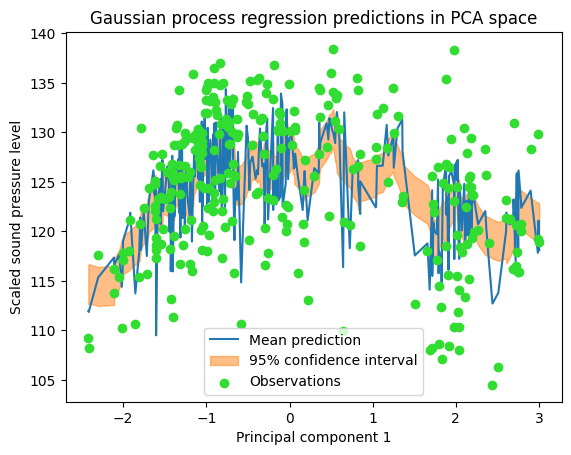

In [16]:
# on fait une pca puis plot pour visualiser la régression gaussienne, en ordonnant d'abord pour que les points soient connectés dans l'ordre de la composante principale 1
X_test_pca = pipeline_pca(1).fit_transform(X_test)
sorted_indices = np.argsort(X_test_pca[:, 0])
X_test_pca_sorted = X_test_pca[sorted_indices]
mean_prediction_sorted = mean_prediction_custom[sorted_indices]
var_prediction_sorted = var_prediction_custom[sorted_indices]


plt.plot(X_test_pca_sorted[:, 0], mean_prediction_sorted, label="Mean prediction")


# on plot aussi les observations et l'intervalle de confiance en utilisant var_prediction_custom
# on plot les intervalles de maniere adoucie pour l'esthetique, en faisant une moyenne mobile sur les bornes inférieures et supérieures
lower = mean_prediction_sorted - 1.96 * np.sqrt(var_prediction_sorted)
upper = mean_prediction_sorted + 1.96 * np.sqrt(var_prediction_sorted)
from scipy.ndimage import uniform_filter1d
lower_smooth = uniform_filter1d(lower, size=10)
upper_smooth = uniform_filter1d(upper, size=10)
plt.fill_between(X_test_pca_sorted[:, 0], lower_smooth, upper_smooth, alpha=0.5, label=r"95% confidence interval", color="C1")


# et les observations
plt.scatter(X_test_pca[:, 0], y_test, label="Observations", color="#30DD30", zorder=3)



plt.xlabel("Principal component 1")
plt.ylabel("Scaled sound pressure level")
plt.title("Gaussian process regression predictions in PCA space")
plt.legend()

